In [48]:
import sympy as sym
import numpy as np
sym.init_printing()

# Parameter / Symbole
m1, m2, m3, alpha, beta, g = sym.symbols('m1 m2 m3 alpha beta g', real=True,positive=True)
# Bedingungen separat definieren
domain_conditions = sym.And(
    sym.StrictGreaterThan(alpha, 0),
    sym.StrictLessThan(alpha, sym.pi/2),
    sym.StrictGreaterThan(beta, 0),
    sym.StrictLessThan(beta, sym.pi/2)
)

In [49]:
eq_x=sym.Eq(-m1*g*sym.cos(alpha)+m3*g*sym.cos(beta),0)
eq_x

In [50]:
eq_y=sym.Eq(m1*g*sym.sin(alpha)+m3*g*sym.sin(beta)-m2*g,0)
eq_y

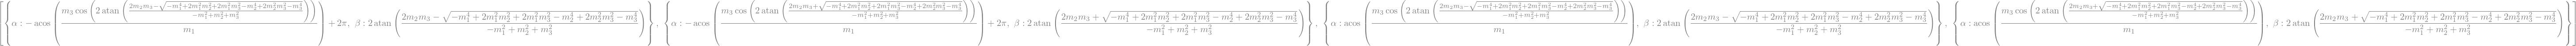

In [51]:
sol_expr=sym.solve([eq_x,eq_y],(alpha,beta),dict=True)
sol_expr

In [59]:
# Setze konkrete Werte für die Symbole in die Lösungen ein
konkrete_werte = {m1: 2.42, m2: 2, m3: 1.90, g: 9.81}

numeric_solutions = []
for sol in sol_expr:
    # numerisch auswerten und in Grad umrechnen
    numeric_sol = {var: float(sym.deg(val.evalf(subs=konkrete_werte))) 
                   for var, val in sol.items()}
    # nur Lösungen zwischen 0° und 90° akzeptieren
    if 0 < numeric_sol[alpha] < 90 and 0 < numeric_sol[beta] < 90:
        # Komplementwinkel berechnen
        numeric_sol = {alpha: numeric_sol[alpha], beta: numeric_sol[beta]}
        numeric_solutions.append(numeric_sol)

print(numeric_solutions)

[{alpha: 40.1873663697557, beta: 13.340456592368124}]


In [60]:
# Berechne die Kraftvektoren für die gefundene Lösung
# Wir nehmen die erste Lösung aus numeric_solutions
winkel = {k: v for k, v in numeric_solutions[0].items()}


# Kräfte berechnen (in Newton)
F1 = konkrete_werte[m1] * konkrete_werte[g]
F2 = konkrete_werte[m2] * konkrete_werte[g]
F3 = konkrete_werte[m3] * konkrete_werte[g]

# Winkel in Radiant umrechnen
alpha_rad = np.deg2rad(winkel[alpha])
beta_rad = np.deg2rad(winkel[beta])

# Kraftvektoren im 2D (x,y)
F1_vec = np.array([-F1 * np.cos(alpha_rad), F1 * np.sin(alpha_rad)])
F2_vec = np.array([0, -F2])
F3_vec = np.array([F3 * np.cos(beta_rad), F3 * np.sin(beta_rad)])

print("F1-Vektor:", F1_vec)
print("F2-Vektor:", F2_vec)
print("F3-Vektor:", F3_vec)

F1-Vektor: [-18.1360488  15.319296 ]
F2-Vektor: [  0.   -19.62]
F3-Vektor: [18.1360488  4.300704 ]


In [61]:
F1_vec[0]+F2_vec[0]+F3_vec[0], F1_vec[1]+F2_vec[1]+F3_vec[1]

In [62]:
np.sqrt(F1_vec[0]**2+F1_vec[1]**2)/9.81, np.sqrt(F3_vec[0]**2+F3_vec[1]**2)/9.81

In [63]:
np.acos(-F1_vec[0]/np.sqrt(F1_vec[0]**2+F1_vec[1]**2))/np.pi*180, np.acos(F3_vec[0]/np.sqrt(F3_vec[0]**2+F3_vec[1]**2))/np.pi*180

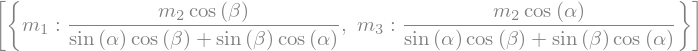

In [58]:
sol_expr_m=sym.solve([eq_x,eq_y],(m1,m3),dict=True)
sol_expr_m